# EDA Pollen 2021-2026 + Random Forest Regressor
**Projet Antihistaminiques France — Jedha 2026**

## Objectif
Analyser les concentrations polliniques 2021-2026 et prédire les graminées du mois suivant avec un Random Forest Regressor — sans données météo.

## Sources
- **RNSA** (2021-2022) — mesures physiques par station
- **CAMS** (2023-2026) — modélisation spatiale Copernicus

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Chargement
df_pollen = pd.read_csv('/Users/nellyta/Jedha/data/silver/J0_silver_pollen_2021_2026.csv')
df_pollen['date'] = pd.to_datetime(df_pollen['date'])

# Agregation par date en gardant la source
pollen_daily = df_pollen.groupby(['date','source']).agg(
    graminees=('graminees_conc','mean'),
    bouleau=('bouleau_conc','mean'),
    aulne=('aulne_conc','mean'),
    ambroisie=('ambroisie_conc','mean'),
    armoise=('armoise_conc','mean'),
    olivier=('olivier_conc','mean')
).reset_index()

pollen_daily['mois']           = pollen_daily['date'].dt.month
pollen_daily['annee']          = pollen_daily['date'].dt.year
pollen_daily['jour_annee']     = pollen_daily['date'].dt.dayofyear
pollen_daily['saison_allergies'] = pollen_daily['mois'].apply(lambda m: 1 if m in [4,5,6,7] else 0)
pollen_daily['source_encoded'] = (pollen_daily['source'] == 'CAMS').astype(int)

mois_noms = {1:'Jan',2:'Fev',3:'Mar',4:'Avr',5:'Mai',6:'Jun',
             7:'Jul',8:'Aou',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

print(f'Pollen : {pollen_daily.shape}')
print(f'Sources : {pollen_daily.source.value_counts().to_dict()}')
print(f'Periode : {pollen_daily.date.min().date()} -> {pollen_daily.date.max().date()}')

Pollen : (1751, 13)
Sources : {'CAMS': 1021, 'RNSA': 730}
Periode : 2021-01-01 -> 2026-06-01


## 1. Evolution temporelle 2021-2026

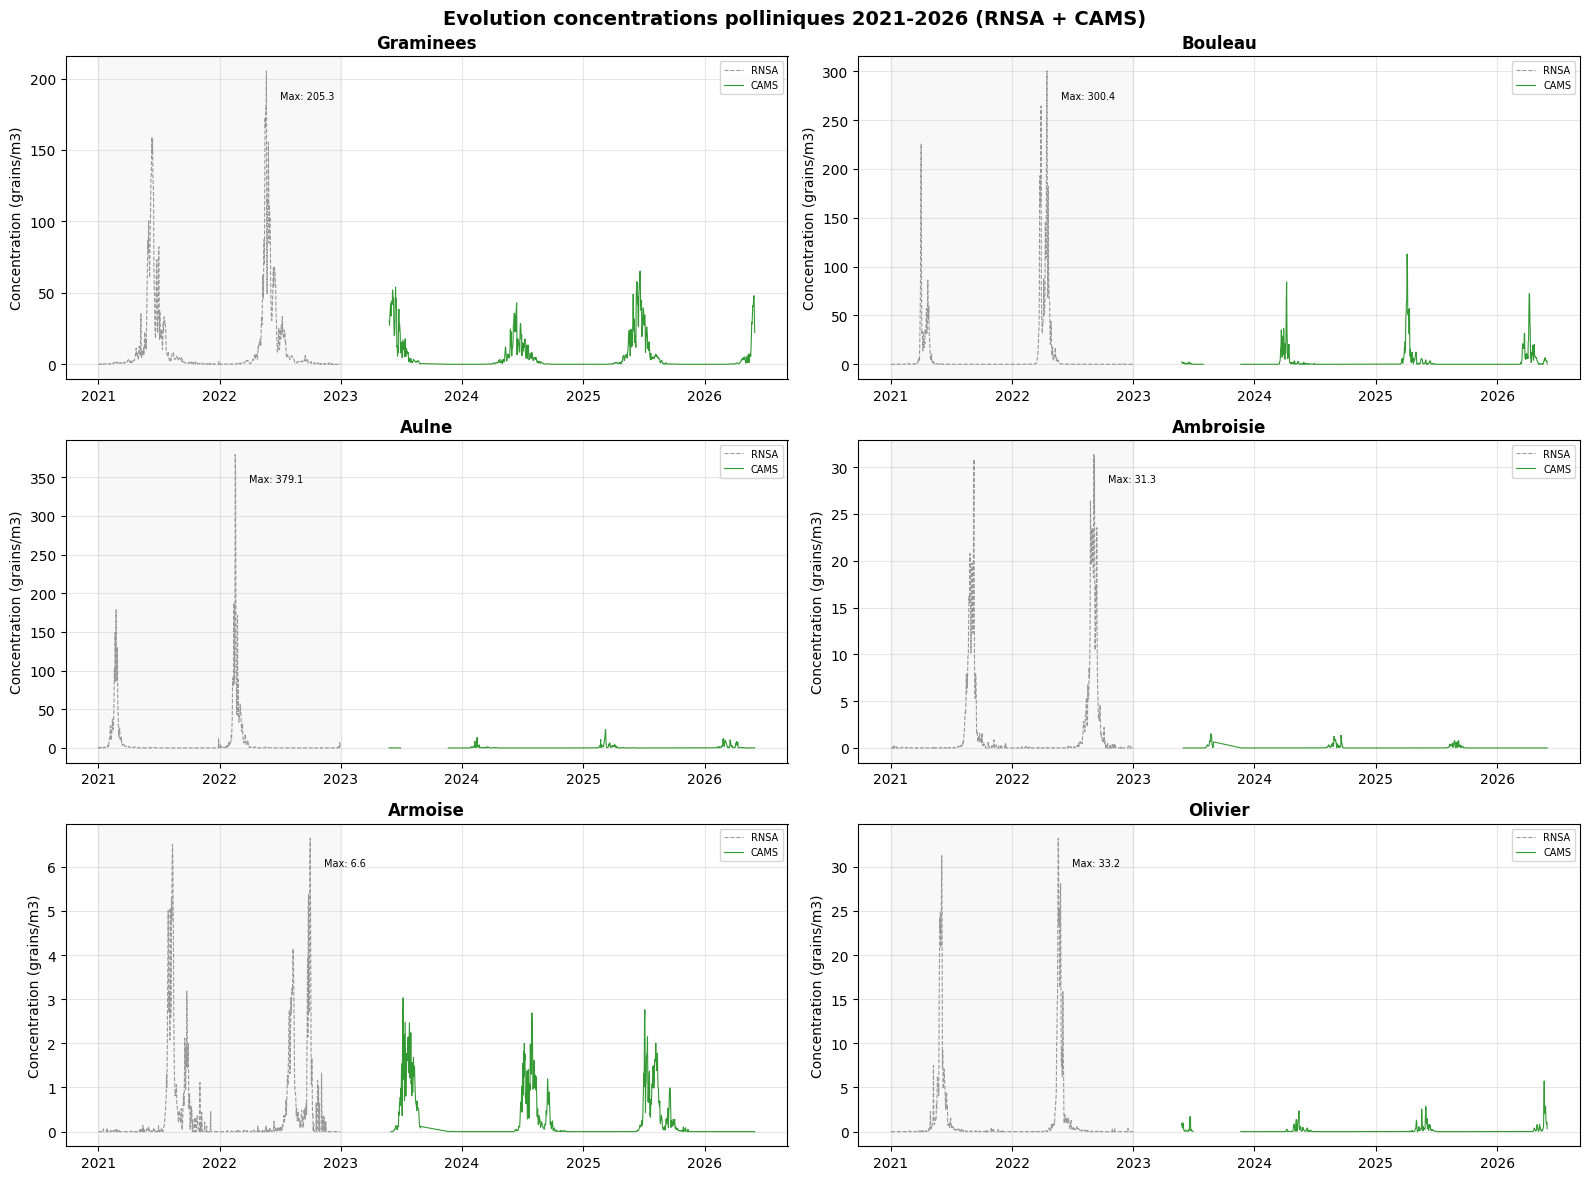

In [2]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Evolution concentrations polliniques 2021-2026 (RNSA + CAMS)',
             fontsize=14, fontweight='bold')

taxons = {
    'graminees': ('Graminees', axes[0,0]),
    'bouleau':   ('Bouleau',   axes[0,1]),
    'aulne':     ('Aulne',     axes[1,0]),
    'ambroisie': ('Ambroisie', axes[1,1]),
    'armoise':   ('Armoise',   axes[2,0]),
    'olivier':   ('Olivier',   axes[2,1]),
}

colors = {'RNSA': 'gray', 'CAMS': 'green'}

for col, (label, ax) in taxons.items():
    for source in ['RNSA', 'CAMS']:
        df_src = pollen_daily[pollen_daily['source'] == source]
        ax.plot(df_src['date'], df_src[col],
                color=colors[source], linewidth=0.8,
                linestyle='--' if source == 'RNSA' else '-',
                label=source, alpha=0.8)
    ax.axvspan(pd.Timestamp('2021-01-01'), pd.Timestamp('2022-12-31'),
               alpha=0.05, color='gray', label='_RNSA zone')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Concentration (grains/m3)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)
    max_val = pollen_daily[col].max()
    max_date = pollen_daily.loc[pollen_daily[col].idxmax(), 'date']
    ax.annotate(f'Max: {max_val:.1f}', xy=(max_date, max_val),
                xytext=(10, -20), textcoords='offset points', fontsize=7)

plt.tight_layout()
plt.savefig('/Users/nellyta/Jedha/notebooks/pollen_evolution_2021_2026.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Saisonnalite par mois — RNSA vs CAMS

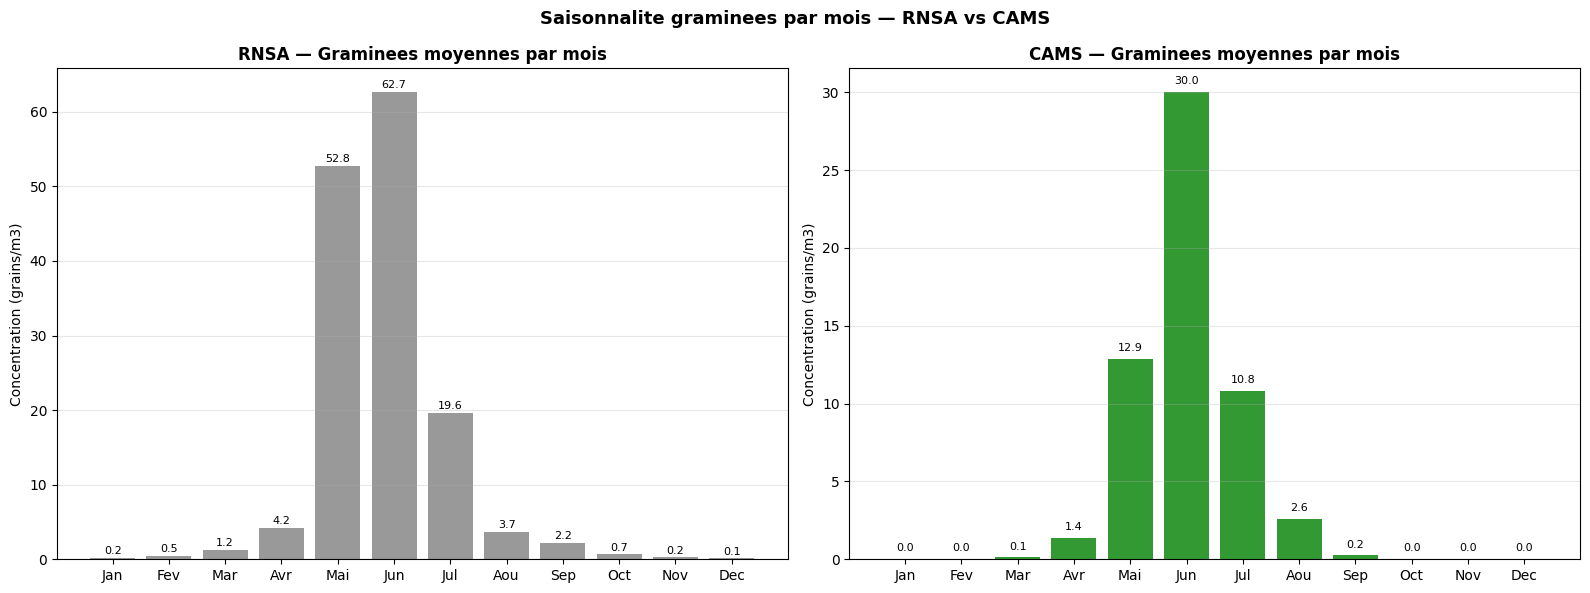

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Saisonnalite graminees par mois — RNSA vs CAMS', fontsize=13, fontweight='bold')

for idx, source in enumerate(['RNSA', 'CAMS']):
    df_src = pollen_daily[pollen_daily['source'] == source]
    saison = df_src.groupby('mois')['graminees'].mean()
    axes[idx].bar([mois_noms[m] for m in saison.index], saison.values,
                  color=colors[source], alpha=0.8)
    axes[idx].set_title(f'{source} — Graminees moyennes par mois', fontweight='bold')
    axes[idx].set_ylabel('Concentration (grains/m3)')
    axes[idx].grid(True, alpha=0.3, axis='y')
    for i, (m, v) in enumerate(saison.items()):
        axes[idx].text(i, v+0.5, f'{v:.1f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('/Users/nellyta/Jedha/notebooks/pollen_saisonnalite_2021_2026.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing — Random Forest Regressor
> **Features** : mois, jour_annee, saison_allergies, source_encoded — pas de météo

> **Variable cible** : gram_moy du mois suivant

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Features uniquement polliniques et temporelles — sans météo
features = ['mois', 'jour_annee', 'saison_allergies', 'source_encoded']

def run_rf(df, label):
    df = df.copy().sort_values('date').reset_index(drop=True)
    df['gram_next'] = df['graminees'].shift(-1)
    df = df.dropna(subset=['gram_next'] + features)

    X = df[features]
    y = df['gram_next']

    if len(df) < 20:
        print(f'  {label} : pas assez de donnees')
        return None, None, None, None

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f'  {label:<25} R2 = {r2:.3f} | RMSE = {rmse:.3f} | n = {len(df)}')
    return y_test, y_pred, r2, rmse

# Resultats
print('=== RANDOM FOREST REGRESSOR — POLLEN UNIQUEMENT ===')
print(f'Features : {features}')
print()

resultats = {}
y_t, y_p, r2, rmse = run_rf(pollen_daily, 'Toutes annees 2021-2026')
if r2 is not None:
    resultats['toutes'] = {'y_test':y_t,'y_pred':y_p,'r2':r2,'rmse':rmse,'label':'Toutes annees 2021-2026','color':'purple'}

colors_annee = {2021:'steelblue',2022:'coral',2023:'mediumseagreen',2024:'mediumpurple',2025:'orange',2026:'red'}
for annee in sorted(pollen_daily['annee'].unique()):
    df_an = pollen_daily[pollen_daily['annee'] == annee]
    y_t, y_p, r2_, rmse_ = run_rf(df_an, f'Annee {annee}')
    if r2_ is not None:
        resultats[annee] = {'y_test':y_t,'y_pred':y_p,'r2':r2_,'rmse':rmse_,
                            'label':f'Annee {annee}','color':colors_annee.get(annee,'purple')}

=== RANDOM FOREST REGRESSOR — POLLEN UNIQUEMENT ===
Features : ['mois', 'jour_annee', 'saison_allergies', 'source_encoded']

  Toutes annees 2021-2026   R2 = 0.345 | RMSE = 12.223 | n = 1750
  Annee 2021                R2 = 0.931 | RMSE = 4.538 | n = 364
  Annee 2022                R2 = 0.996 | RMSE = 1.498 | n = 364
  Annee 2023                R2 = 0.937 | RMSE = 3.992 | n = 137
  Annee 2024                R2 = 0.214 | RMSE = 3.671 | n = 365
  Annee 2025                R2 = 0.929 | RMSE = 1.957 | n = 364
  Annee 2026                R2 = 0.990 | RMSE = 1.025 | n = 151


## 4. Graphiques Random Forest

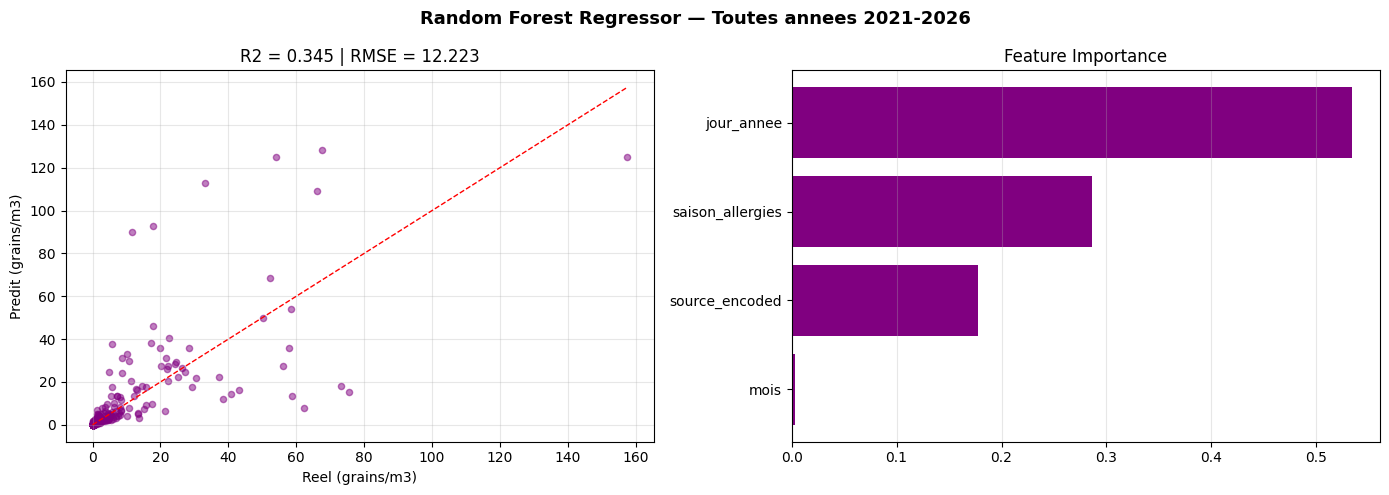

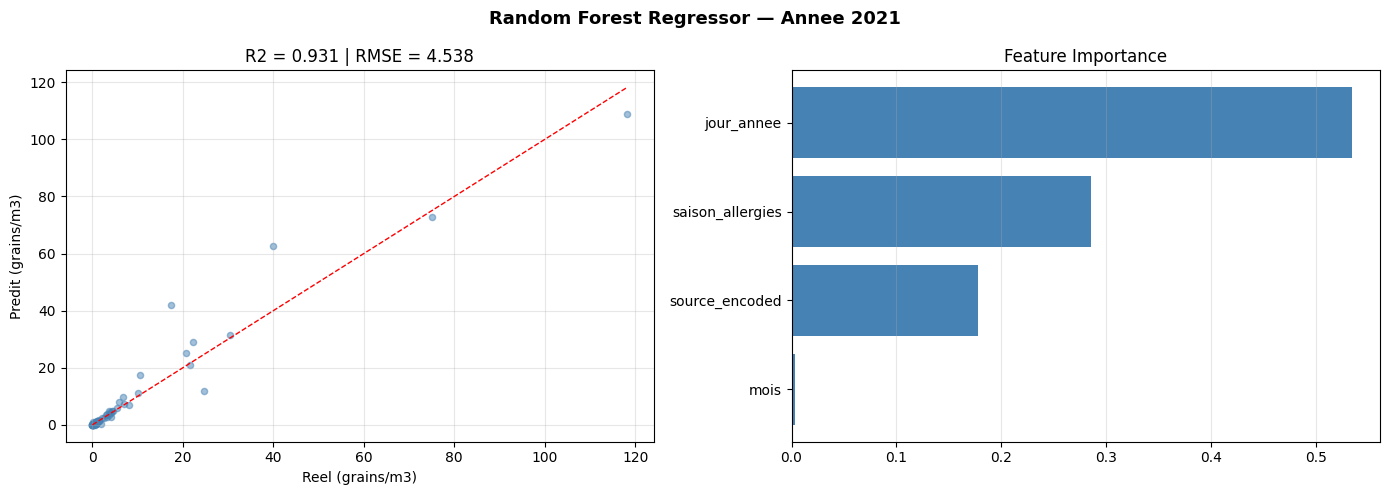

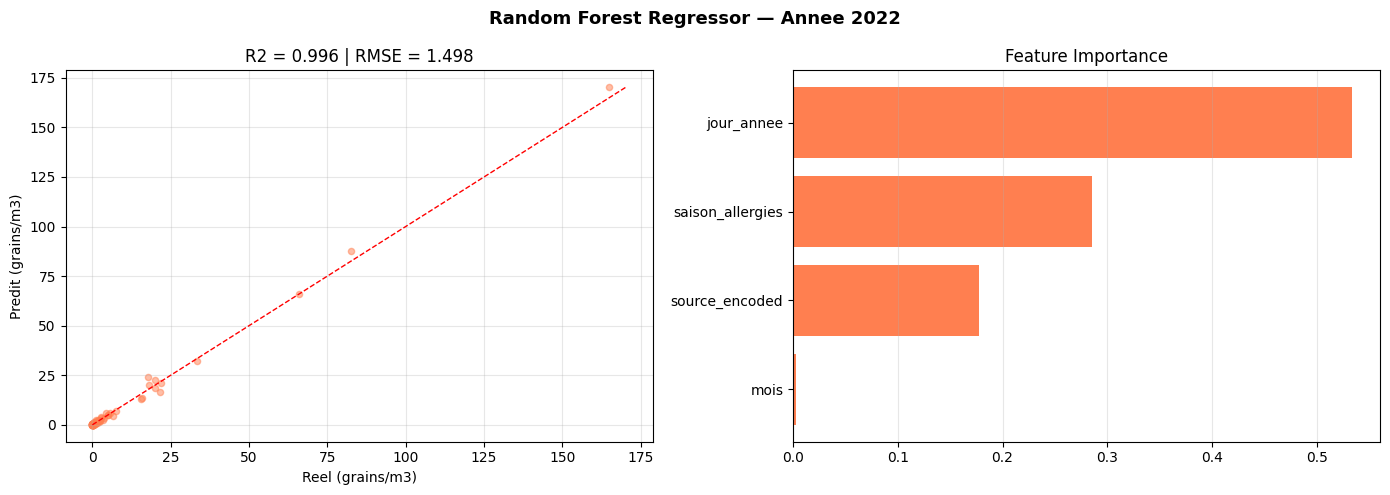

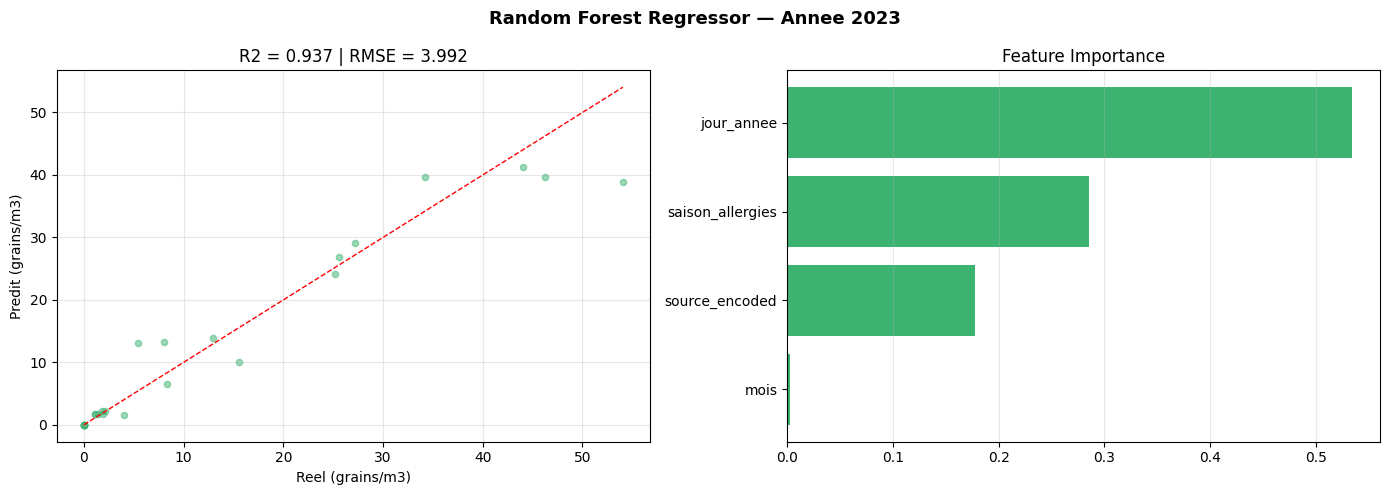

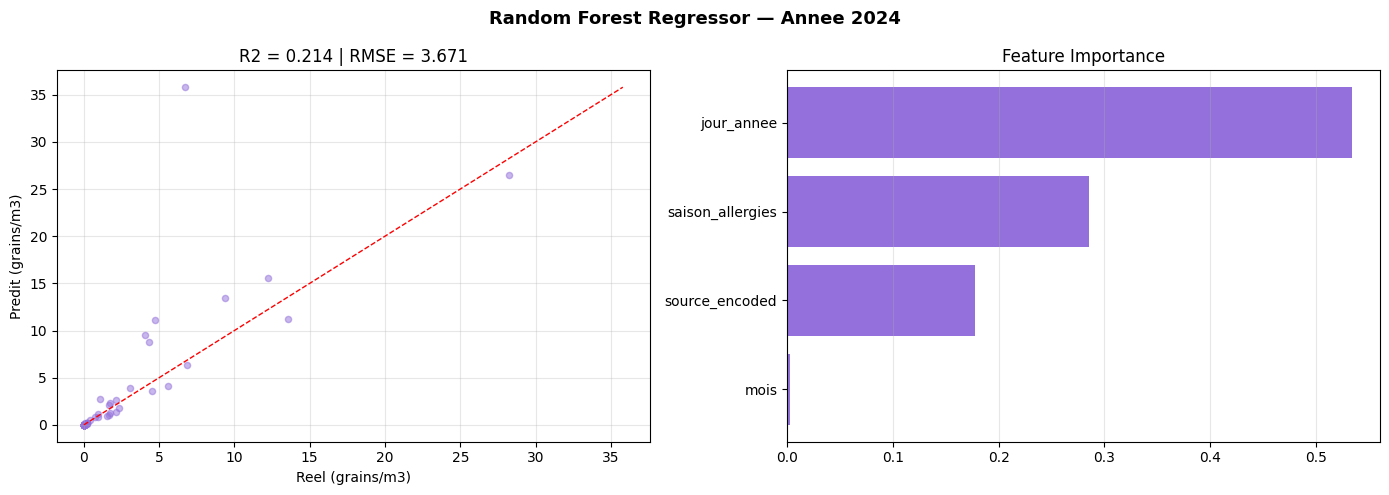

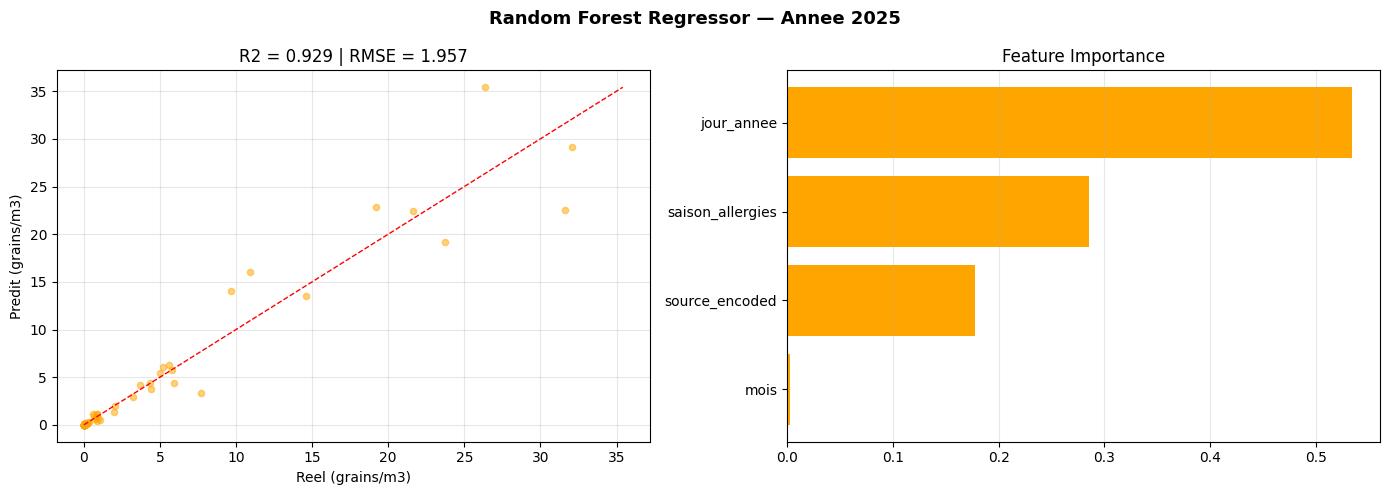

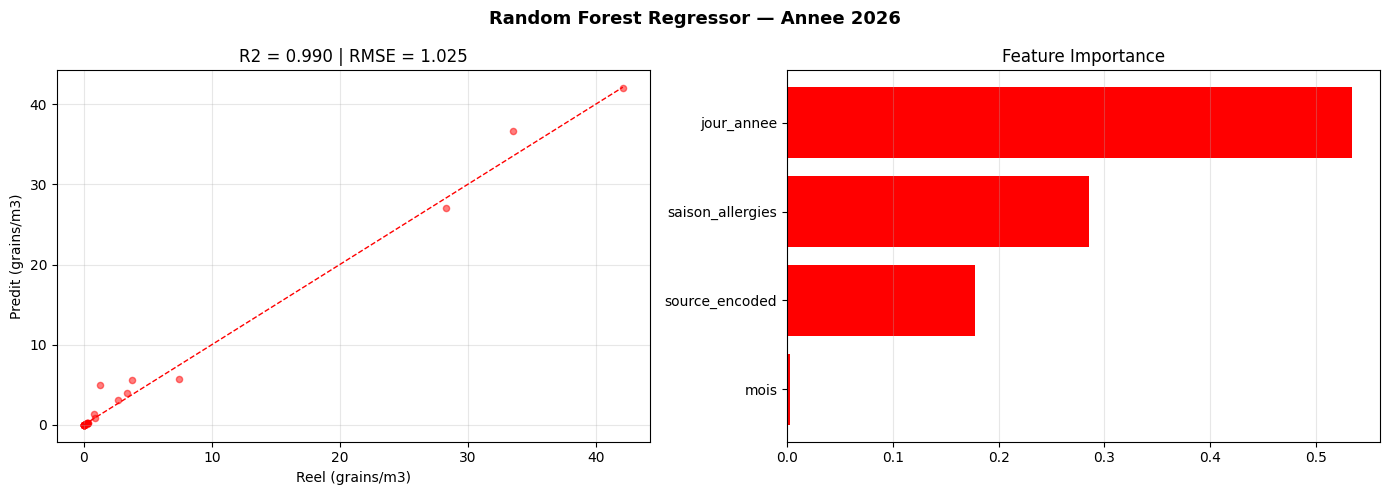

In [5]:
def plot_rf(res):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Random Forest Regressor — {res['label']}", fontsize=13, fontweight='bold')

    # Reel vs predit
    axes[0].scatter(res['y_test'], res['y_pred'], alpha=0.5, color=res['color'], s=20)
    max_val = max(float(res['y_test'].max()), float(res['y_pred'].max()))
    axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1)
    axes[0].set_xlabel('Reel (grains/m3)')
    axes[0].set_ylabel('Predit (grains/m3)')
    axes[0].set_title(f"R2 = {res['r2']:.3f} | RMSE = {res['rmse']:.3f}")
    axes[0].grid(True, alpha=0.3)

    # Feature importance
    df_an = pollen_daily.copy().sort_values('date').reset_index(drop=True)
    df_an['gram_next'] = df_an['graminees'].shift(-1)
    df_an = df_an.dropna(subset=['gram_next'] + features)
    rf_tmp = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_tmp.fit(df_an[features], df_an['gram_next'])
    imp = pd.DataFrame({'feature':features,'importance':rf_tmp.feature_importances_}).sort_values('importance', ascending=True)
    axes[1].barh(imp['feature'], imp['importance'], color=res['color'])
    axes[1].set_title('Feature Importance')
    axes[1].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    fname = res['label'].replace(' ','_').replace('-','_')
    plt.savefig(f"/Users/nellyta/Jedha/notebooks/rf_pollen_{fname}.png", dpi=150, bbox_inches='tight')
    plt.show()

for key in resultats:
    plot_rf(resultats[key])

## 5. Synthese

In [6]:
print('=' * 60)
print('SYNTHESE EDA POLLEN 2021-2026')
print('=' * 60)
print(f"  Periode      : {pollen_daily.date.min().date()} -> {pollen_daily.date.max().date()}")
print(f"  Jours RNSA   : {(pollen_daily.source=='RNSA').sum()}")
print(f"  Jours CAMS   : {(pollen_daily.source=='CAMS').sum()}")
print()
print('PICS PAR TAXON')
for taxon in ['graminees','bouleau','aulne','ambroisie','armoise','olivier']:
    mois_pic = pollen_daily.groupby('mois')[taxon].mean().idxmax()
    val_max  = pollen_daily[taxon].max()
    print(f'  {taxon:<12} -> pic en {mois_noms[mois_pic]}, max = {val_max:.1f} grains/m3')
print()
print('RANDOM FOREST — FEATURES POLLEN UNIQUEMENT')
for k, v in resultats.items():
    print(f"  {v['label']:<25} R2 = {v['r2']:.3f} | RMSE = {v['rmse']:.3f}")
print()
print('NOTE METHODOLOGIQUE')
print('  RNSA (2021-2022) : mesures physiques stations — echelle plus elevee')
print('  CAMS (2023-2026) : modelisation spatiale — echelle plus basse')
print('  source_encoded = 1 si CAMS, 0 si RNSA — permet au modele de corriger le biais')

SYNTHESE EDA POLLEN 2021-2026
  Periode      : 2021-01-01 -> 2026-06-01
  Jours RNSA   : 730
  Jours CAMS   : 1021

PICS PAR TAXON
  graminees    -> pic en Jun, max = 205.3 grains/m3
  bouleau      -> pic en Avr, max = 300.4 grains/m3
  aulne        -> pic en Fev, max = 379.1 grains/m3
  ambroisie    -> pic en Sep, max = 31.3 grains/m3
  armoise      -> pic en Aou, max = 6.6 grains/m3
  olivier      -> pic en Mai, max = 33.2 grains/m3

RANDOM FOREST — FEATURES POLLEN UNIQUEMENT
  Toutes annees 2021-2026   R2 = 0.345 | RMSE = 12.223
  Annee 2021                R2 = 0.931 | RMSE = 4.538
  Annee 2022                R2 = 0.996 | RMSE = 1.498
  Annee 2023                R2 = 0.937 | RMSE = 3.992
  Annee 2024                R2 = 0.214 | RMSE = 3.671
  Annee 2025                R2 = 0.929 | RMSE = 1.957
  Annee 2026                R2 = 0.990 | RMSE = 1.025

NOTE METHODOLOGIQUE
  RNSA (2021-2022) : mesures physiques stations — echelle plus elevee
  CAMS (2023-2026) : modelisation spatiale — ec